# Machine Learning: Assignment 2
## KMeans clustering (max. 7p)

**Remember** to write your information below.

In [16]:
# TODO: Write your information here!
student_name = 'Jaka Cosic Hämäläinen'
student_email = "aa6111@student.jamk.fi"

## Assignment 2.0: KMeans assignment
### Unsupervised learning
In the assignment, three (3) distinct clusters are generated using **synthetic values** of X and y coordinates.

These can be drawn in the (X,Y) coordinate system.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def k_mean_distance(data, cx, cy, i_centroid, cluster_labels):    
    #  TODO: Function implementation to calculate the mean of distances of cluster centroids
    cluster_points = data[cluster_labels == i_centroid]
    centroid_x, centroid_y = cx[i_centroid], cy[i_centroid]
    distances = np.sqrt((cluster_points[:, 0] - centroid_x) ** 2 + (cluster_points[:, 1] - centroid_y) ** 2)
    return np.mean(distances)


## Assignment 2.1
### Topic: Generation of synthetic data points (2 points)

Let's generate random data into a NumPy matrix and divide the array into the four (4) cluster of points.
* Each part includes **100** coordinate pairs. 
* The total number of elements in the array is **400 coordinate pairs**.

The points are generated, for example, with NumPy's function `np.random.rand()`.

The four cluster of points is generated with random numbers using the following *calculation formulas*:

* **100** points with (x, y) values between **[-1, 0]**
* **100** points with (x, y) values between **[1, 2]**
* **100** points with (x, y) values between **[3, 4]**
* **100** points with (x, y) values between **[3.5, 4.5]**

In [18]:
# TODO: Generate a total of 400 points, all with values in separate value sets
# TODO: Combine the values of the generated arrays into a single array.
# TODO: shuffle the values before the next step.
X = [[]]

cluster_1 = np.random.uniform(-1, 0, (100, 2))
cluster_2 = np.random.uniform(1, 2, (100, 2))
cluster_3 = np.random.uniform(3, 4, (100, 2))
cluster_4 = np.random.uniform(3.5, 4.5, (100, 2))

X = np.vstack((cluster_1, cluster_2, cluster_3, cluster_4))

np.random.shuffle(X)

# Print the size of the array.
print(f"Length of matrix: {len(X)}")

Length of matrix: 400


## Assignment 2.2
### Topic: K-Means clustering and plotting (2 points)

Perform **clustering** on the dataset using the `cluster` module of `scikit-learn` library
[k-means method](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.k_means.html).

When using the **KMeans** algorithm, the number of possible clusters can be set in advance, but here the algorithm is run with defaults.

Additional tip you should try in this assignment:

The algorithm of the **KMeans** machine learning model can be tuned in a variety of ways (the same applies to other ML implementations of sklearn) by changing the parameters.

     KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
      n_clusters=2, n_init=10, n_jobs=1, precompute_distances='auto',
      random_state=None, tol=0.0001, verbose=0)``

In [19]:
import warnings  # Disable specific warning

warnings.simplefilter(action='ignore', category=UserWarning)

kmeans = KMeans(init='random', n_clusters=4, n_init=30, random_state=42)  # 4 clusters (matching the synthetic data)
kmeans.fit(X)


KMeans(init='random', n_clusters=4, n_init=30, random_state=42)

Let's find the center points (**centroids**) of the clusters.
Hint: `cluster_centers_`

In [20]:
# TODO: Retrieve cluster centers (centroids)
centroids = kmeans.cluster_centers_

# The center points of the clusters and their number are printed out
print(f"Number of centroids {len(centroids)} and positions: {centroids}")

Number of centroids 4 and positions: [[ 3.54277547  3.43772911]
 [ 1.48093466  1.49219849]
 [-0.52428145 -0.51771912]
 [ 3.93207099  4.05468645]]


Drawing clusters and centroids

Let's plot all the data points using a scatter plot.
* the calculated center points are plotted
Hint: `plt.scatter`

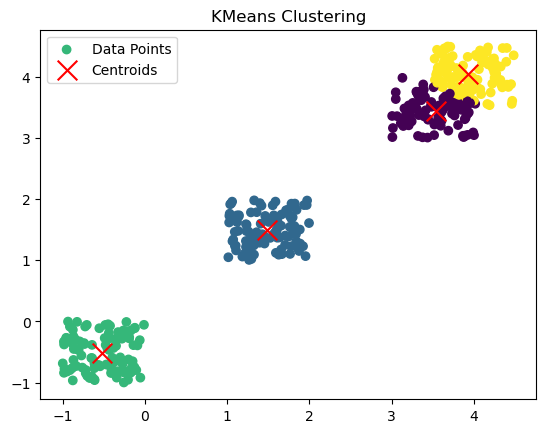

In [21]:
# TODO: Plot the points as a scatter plot

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', marker='o', label='Data Points')

# TODO: plot the calculated centroids

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')

plt.title("KMeans Clustering")
plt.legend()
plt.show()

## Assignment 2.3
### Topic: K-Means clustering - setting the number of cluster centroids (2 points)

Set the number of cluster centroids to *optimal number* of clusters.
The optimal number of clusters can be seen by examining the distribution of points using the figure.

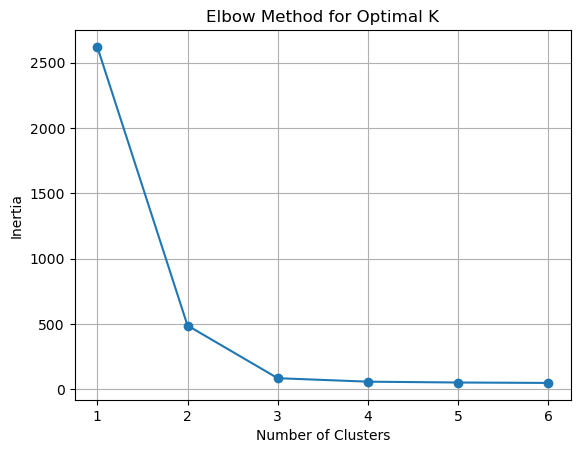

Number of centroids 3 and positions: [[ 1.48093466  1.49219849]
 [ 3.74131618  3.75237735]
 [-0.52428145 -0.51771912]]


In [22]:
# TODO: Set the optimal number of clusters

inertia = []
clusters_range = range(1,7)

for k in clusters_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(clusters_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Based on the Elbow curve
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k)
kmeans.fit(X)

# TODO: Retrieving cluster centroids

centroids = kmeans.cluster_centers_

labels = kmeans.predict(X)

# The center points of the clusters and their number are printed
print(f"Number of centroids {len(centroids)} and positions: {centroids}")

#### Visualize: Drawing clusters and centroids

Let's plot all the data points using a scatter plot.
* the calculated centroids are plotted
Hint: `plt.scatter`

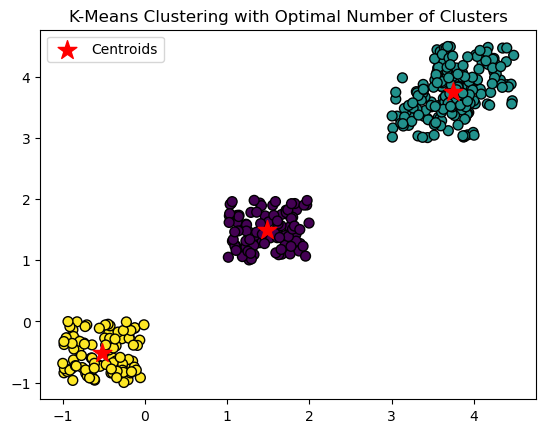

In [23]:
# TODO: Plot the points as a scatter plot

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, marker='o', edgecolors='k')

# TODO: plot the calculated centroids

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='*', label='Centroids')

plt.title('K-Means Clustering with Optimal Number of Clusters')
plt.legend()
plt.show()

## Assignment 2.4:
### Topic: Cluster distances as a line diagram (1 p)

Let's plot the average distances of the points of the clusters from the center of the cluster.
* implement the *k_mean_distance()* function given at the beginning of this document is used for drawing


In [24]:
# TODO: Calculate and plot the average distances of cluster points from the cluster centroid
distances_from_center = []


# plt.plot(distances_from_center)
# plt.show()